## Set up data and model objects


In [1]:
import pandas as pd
import numpy as np
import mudata as md
from perturbo import run_svi, run_mcmc, perturbseq_guide_autonormal, perturbseq_model
import seaborn as sns
import matplotlib.pyplot as plt
import jax.numpy as jnp

smoke_test = True  # only use selected genes
# smoke_test=False # run full analysis

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


Set training configuration and access to data


### Load the data

(50k cells, takes ~30 seconds)


In [2]:
data_dir = "../../../../Data/gasperini_pilot"

mdata = md.read_h5mu(f"{data_dir}/gasperini_pilot_highMOI.h5mu")
# batch_size=None
mdata

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


MuData object with n_obs × n_vars = 47964 × 19482
  2 modalities
    rna:	47964 x 16367
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 3115
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [3]:
mdata["grna"]

AnnData object with n_obs × n_vars = 47964 × 3115
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
    varm: 'element_targeted'

In [4]:
element = "ACTB_TSS"
# element = "ACTG1_TSS"

element_guides = mdata["grna"].varm["element_targeted"][element]
element_guides

ACTB_TSS|1       1.0
ACTB_TSS|2       1.0
ACTG1_TSS|1      0.0
ACTG1_TSS|2      0.0
ACYP1_TSS|1      0.0
                ... 
scrambled_7|2    0.0
scrambled_8|1    0.0
scrambled_8|2    0.0
scrambled_9|1    0.0
scrambled_9|2    0.0
Name: ACTB_TSS, Length: 3115, dtype: float32

In [5]:
control_guides = pd.Series(np.zeros(len(element_guides)), index=element_guides.index)
control_guides[-50:] = 1
control_guides

ACTB_TSS|1       0.0
ACTB_TSS|2       0.0
ACTG1_TSS|1      0.0
ACTG1_TSS|2      0.0
ACYP1_TSS|1      0.0
                ... 
scrambled_7|2    1.0
scrambled_8|1    1.0
scrambled_8|2    1.0
scrambled_9|1    1.0
scrambled_9|2    1.0
Length: 3115, dtype: float64

In [6]:
selected_guides = element_guides + control_guides
selected_cells = mdata["grna"].X @ selected_guides
selected_cells = selected_cells.astype(bool)
selected_cells.sum()

13052

In [7]:
grna_subset = mdata["grna"][:, element_guides > 0]
grna_subset = grna_subset[selected_cells, :]
grna_subset

View of AnnData object with n_obs × n_vars = 13052 × 2
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
    varm: 'element_targeted'

In [8]:
gene = "ACTB"
rna_subset = mdata["rna"][:, gene]
rna_subset = rna_subset[selected_cells, :]
rna_subset

View of AnnData object with n_obs × n_vars = 13052 × 1
    obs: 'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
    varm: 'element_tested'

In [9]:
cell_covariates = rna_subset.obs[["log_total_gene_count", "percent_mito", "log_total_guide_count"]].values
cell_covariates

array([[8.38571683, 0.0290571 , 7.33040524],
       [8.25478893, 0.02597587, 5.9864521 ],
       [8.41183268, 0.04182922, 5.69709349],
       ...,
       [8.37724123, 0.02736576, 6.2324481 ],
       [8.13739583, 0.02731629, 6.20050907],
       [8.52038808, 0.02861614, 6.12468338]])

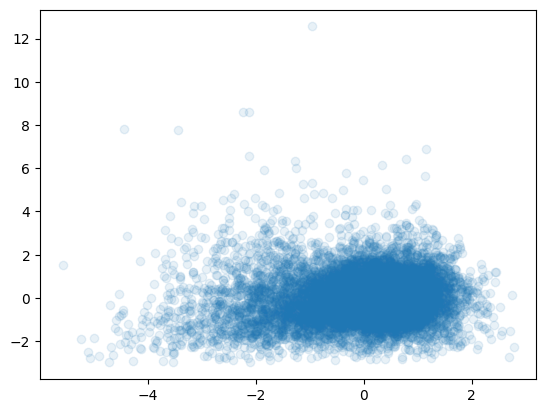

In [10]:
feature_means = cell_covariates.mean(axis=0)
feature_stds = cell_covariates.std(axis=0)
feature_medians = np.median(cell_covariates, axis=0)
feature_mads = np.median(np.abs(cell_covariates - feature_medians), axis=0)

cell_covariates_z_scored = (cell_covariates - feature_means) / feature_stds

plt.scatter(x=cell_covariates_z_scored[:, 0], y=cell_covariates_z_scored[:, 1], alpha=0.1)

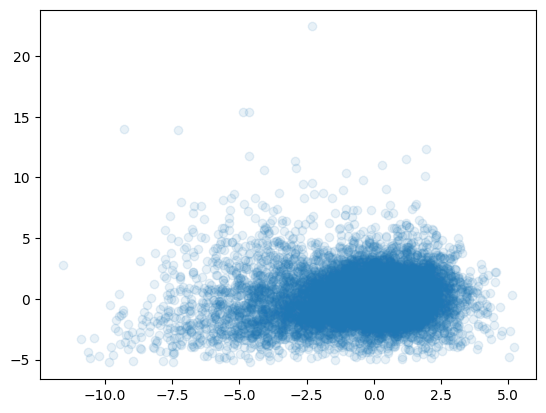

In [11]:
cell_covariates_robust_z_scored = (cell_covariates - feature_medians) / feature_mads
plt.scatter(x=cell_covariates_robust_z_scored[:, 0], y=cell_covariates_robust_z_scored[:, 1], alpha=0.1)

In [12]:
gene_obs = jnp.array(rna_subset.X.toarray())
guide_obs = jnp.array(grna_subset.X)
# guide_obs = guide_obs.at[:, 2:].set(0)
guide_obs.shape

(13052, 2)

-0.66280335
-0.48440433


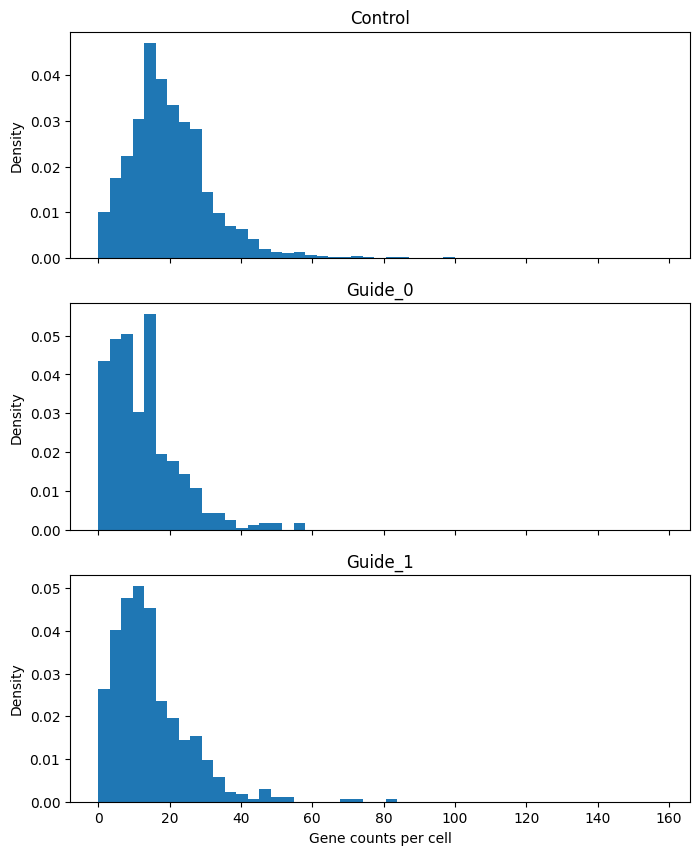

In [13]:
hist_bins = np.linspace(0, gene_obs.max(), 50)

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(8, 10))

# Control histogram
control_gene_obs = gene_obs[guide_obs.sum(axis=1) == 0, :].squeeze()
axs[0].hist(control_gene_obs, bins=hist_bins, density=True)
axs[0].set_ylabel("Density")
axs[0].set_title("Control")

# Guide histograms
guides_gene_obs = []
for i in range(guide_obs.shape[1]):
    guide_gene_obs = gene_obs[guide_obs[:, i].astype(bool), :].squeeze()
    print(np.log2(guide_gene_obs.mean() / control_gene_obs.mean()))
    guides_gene_obs.append(guide_gene_obs)
    axs[i + 1].hist(guide_gene_obs, bins=hist_bins, density=True)
    axs[i + 1].set_ylabel("Density")
    axs[i + 1].set_title(f"Guide_{i}")

plt.xlabel("Gene counts per cell")
plt.show()

In [14]:
perturbseq_guide = perturbseq_guide_autonormal()
model_args = (gene_obs,)
model_kwargs = {
    "guide_obs": guide_obs,
    "covariates": cell_covariates_robust_z_scored,
    "likelihood": "NegBin",
    "effect_type": "scale",
    "subsample_size": 1000,
}

svi_result = run_svi(
    model_args,
    model_kwargs,
    perturbseq_model,
    perturbseq_guide,
    lr=0.1,
    n_steps=200,
)

100%|██████████| 200/200 [00:01<00:00, 114.28it/s, init loss: 654805.3125, avg. loss [191-200]: 66104.7129]


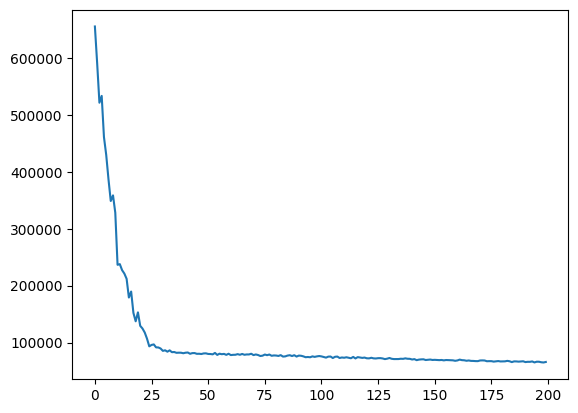

In [15]:
plt.plot(svi_result.losses)

In [16]:
params = svi_result.params
params

{'covariate_weights_auto_loc': Array([[ 0.23622994],
        [-0.09173992],
        [-0.03643203]], dtype=float32),
 'covariate_weights_auto_scale': Array([[0.02401104],
        [0.02648717],
        [0.01375813]], dtype=float32),
 'dispersion_auto_loc': Array([0.73072153], dtype=float32),
 'dispersion_auto_scale': Array([0.11091612], dtype=float32),
 'efficiency_auto_loc': Array([[0.22462507],
        [1.0516063 ]], dtype=float32),
 'efficiency_auto_scale': Array([[2.8192613],
        [2.8858705]], dtype=float32),
 'log2_fold_change_auto_loc': Array([0.03234939], dtype=float32),
 'log2_fold_change_auto_scale': Array([0.06758361], dtype=float32),
 'mean_auto_loc': Array([2.9381266], dtype=float32),
 'mean_auto_scale': Array([0.07216769], dtype=float32)}

In [17]:
perturbseq_guide.median(params)

{'mean': Array([18.880442], dtype=float32),
 'dispersion': Array([2.0765784], dtype=float32),
 'efficiency': Array([[0.5559213 ],
        [0.74108326]], dtype=float32),
 'log2_fold_change': Array([0.03234939], dtype=float32),
 'covariate_weights': Array([[ 0.23622994],
        [-0.09173992],
        [-0.03643203]], dtype=float32)}

In [18]:
unconstrained_locs = {}
for k, v in svi_result.params.items():
    param, param_type = k.split("_auto_")
    if param_type == "loc":
        unconstrained_locs[param] = v
mcmc_model_kwargs = {k: v for k, v in model_kwargs.items() if k != "subsample_size"}
mcmc_result = run_mcmc(model_args, mcmc_model_kwargs, unconstrained_locs)

sample: 100%|██████████| 2000/2000 [00:44<00:00, 44.84it/s, 31 steps of size 1.17e-01. acc. prob=0.91]


In [19]:
mcmc_posterior_samples = mcmc_result.get_samples()
mcmc_posterior_samples.keys()

dict_keys(['covariate_weights', 'dispersion', 'efficiency', 'log2_fold_change', 'mean'])

(1000, 3)


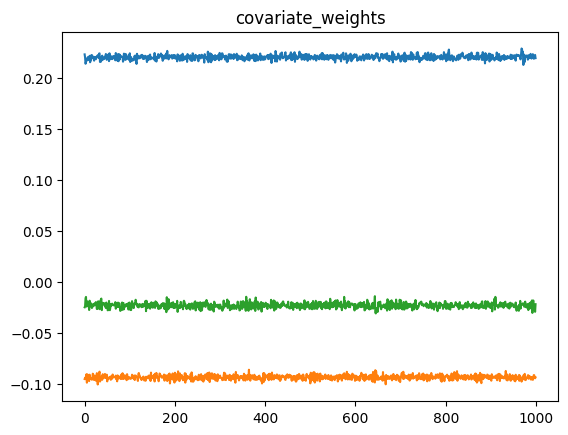

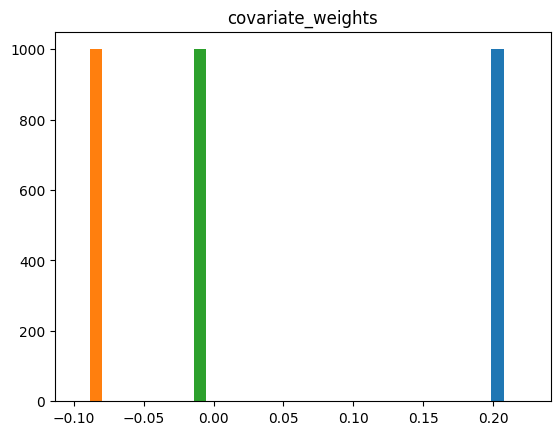

(1000,)


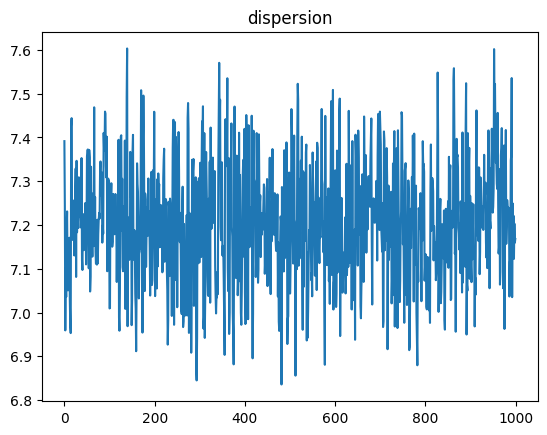

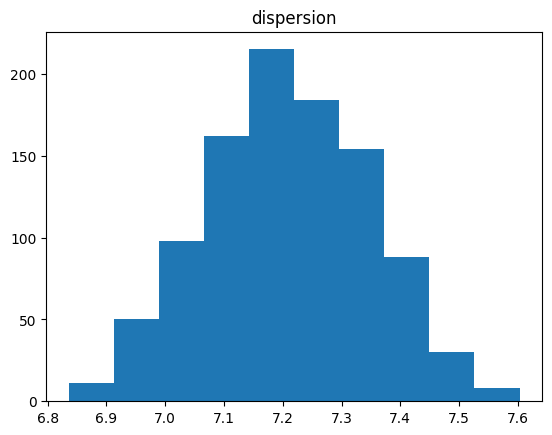

(1000, 2)


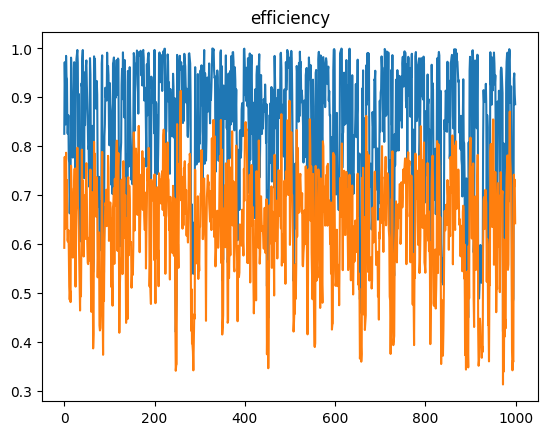

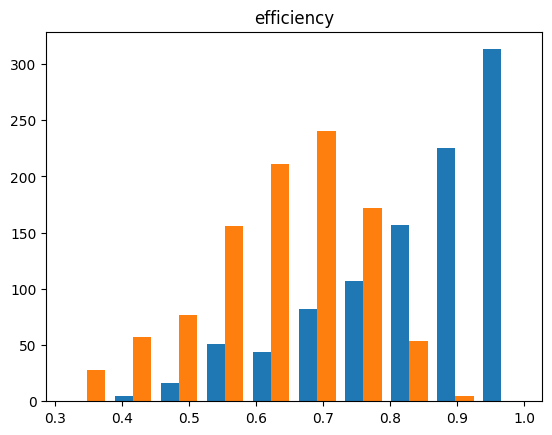

(1000,)


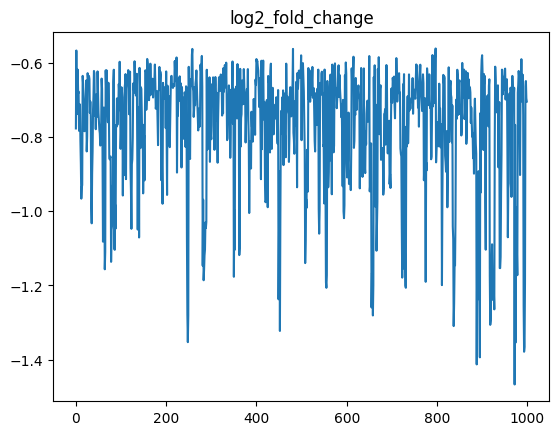

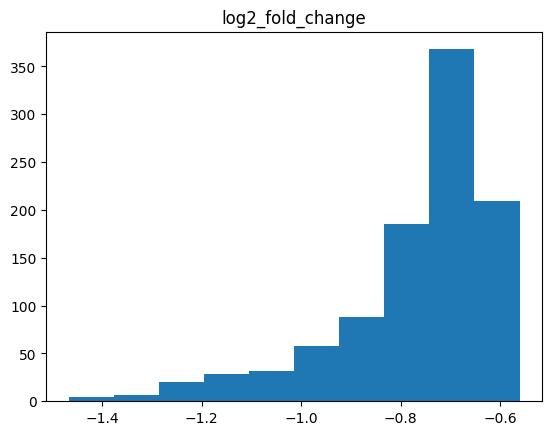

(1000,)


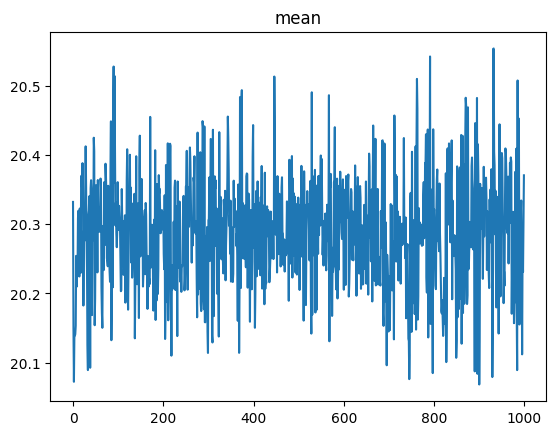

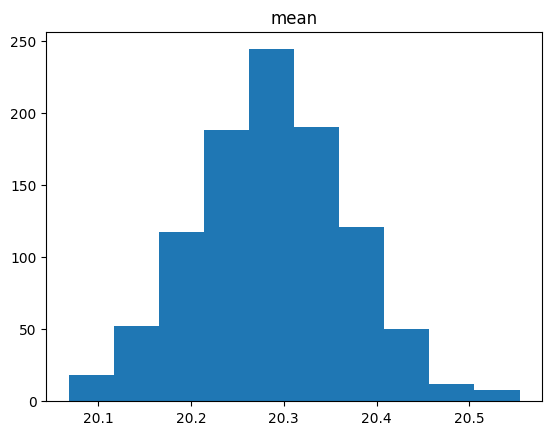

In [20]:
for k in mcmc_posterior_samples:
    samples_k = mcmc_posterior_samples[k].squeeze()
    print(samples_k.shape)
    if len(samples_k.shape) > 2:
        continue

    plt.plot(samples_k)
    plt.title(k)
    plt.show()

    if len(samples_k.shape) == 2 and samples_k.shape[0] > 1:
        samples_k = samples_k.T

    plt.hist(samples_k)
    plt.title(k)
    plt.show()